# AICE Associate 예상 문제 8회: 대출 승인 여부 예측

**과제: 고객 데이터 기반 대출 승인 여부 예측 AI 모델 개발**

**도메인: 금융**

**배경:**
금융 기관에서 대출 승인 심사는 리스크 관리의 핵심적인 부분입니다. 'AICE 캐피탈'의 리스크 관리팀은 과거 대출 신청 고객들의 데이터를 분석하여, 어떤 요인이 대출 승인 및 거절에 영향을 미치는지 파악하고자 합니다. 이를 바탕으로 신규 대출 신청 건에 대해 승인 가능성을 자동으로 예측하는 AI 모델을 개발하는 것이 목표입니다. 이 모델은 심사 과정의 효율성을 높이고, 일관성 있는 의사결정을 내리는 데 도움을 줄 것입니다.

**데이터셋 설명 (파일명: `8_loan_approval.csv`)**

* `employment_type`: 고용 형태
* `annual_income`: 연소득 (만원)
* `credit_score`: 신용 점수
* `loan_purpose`: 대출 목적
* `loan_amount`: 대출 신청 금액 (만원)
* `dti`: 부채 비율 (%)
* `years_employed`: 고용 기간 (년)
* `home_ownership`: 주택 소유 여부
* `delinquency_history`: 과거 연체 이력 유무
* **`loan_status`**: **예측 목표(Target)**, 대출 승인 여부 (1: 승인, 0: 거절)

--- 
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [3]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

--- 
#### **문제 1.**

Scikit-learn 라이브러리의 `ensemble` 모듈에는 여러 개의 약한 학습기를 결합하여 성능을 높이는 앙상블 모델들이 포함되어 있습니다. `sklearn.ensemble` 모듈에서 `AdaBoostClassifier` 클래스를 임포트하는 코드를 작성하세요.

In [2]:
from sklearn.ensemble import AdaBoostClassifier

#### **[해설 및 핵심 이론] 문제 1**


* **상세 해설**

    `from 패키지.모듈 import 클래스` 구문을 사용하여 `sklearn.ensemble` 모듈에서 `AdaBoostClassifier` 클래스를 불러옵니다. AdaBoost는 이전 모델이 잘못 예측한 데이터에 가중치를 부여하여 다음 모델이 더 잘 맞추도록 하는 부스팅(Boosting) 계열의 앙상블 모델입니다.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

--- 
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 기본적인 정보를 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `9_loan_approval.csv` 파일을 읽어 데이터프레임 변수 `loan_df`에 할당하세요.
2.  `info()` 함수를 사용하여 `loan_df`의 요약 정보를 확인하여 결측치와 데이터 타입을 파악하세요.

In [4]:
loan_df = pd.read_csv('8_loan_approval.csv')

loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employment_type      1740 non-null   str    
 1   annual_income        1744 non-null   float64
 2   credit_score         1738 non-null   float64
 3   loan_purpose         1743 non-null   str    
 4   loan_amount          1758 non-null   float64
 5   dti                  1753 non-null   float64
 6   years_employed       1745 non-null   float64
 7   home_ownership       1728 non-null   str    
 8   delinquency_history  1737 non-null   str    
 9   loan_status          1800 non-null   int64  
dtypes: float64(5), int64(1), str(4)
memory usage: 140.8 KB


#### **[해설 및 핵심 이론] 문제 2**


* **상세 해설**
  
    `pandas`의 `read_csv()` 함수로 데이터를 불러온 후, `info()` 메소드를 사용하여 데이터프레임의 전체적인 구조, 각 컬럼의 데이터 타입, 결측치 현황 등을 파악합니다. 실행 결과를 통해 여러 컬럼에 결측치가 존재함을 확인할 수 있습니다.

In [ ]:
# '8_loan_approval.csv' 파일을 읽어 loan_df 변수에 저장합니다.
loan_df = pd.read_csv('C:\\Users\\User\\Desktop\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\2026 이패스 AI능력시험 AI Associate 실전모의고사 10_DATA\\8_loan_approval.csv')

# 데이터프레임의 요약 정보 확인
loan_df.info()

--- 
#### **문제 3.**

`신용점수(credit_score)`가 `대출승인여부(loan_status)`에 따라 어떻게 다른 분포를 보이는지 시각적으로 탐색하고자 합니다.  
`seaborn`의 `violinplot`을 사용하여 두 그룹의 `credit_score` 분포를 비교하세요.

* **x축**: `loan_status`
* **y축**: `credit_score`
* **데이터**: `loan_df`

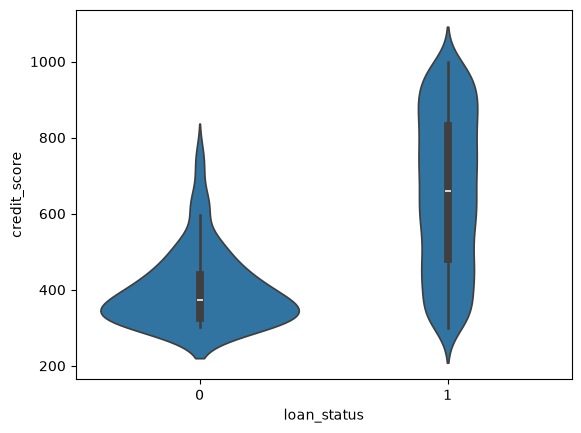

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.violinplot(data=loan_df, x='loan_status', y='credit_score')
plt.show()

#### **[해설 및 핵심 이론] 문제 3**


* **상세 해설**
  
    `violinplot`은 `boxplot`과 데이터의 밀도 그래프를 합친 형태로, 각 그룹의 데이터 분포를 더 상세하게 보여줍니다. `x`축에 `loan_status`, `y`축에 `credit_score`를 설정하면, 대출이 승인된 그룹(1)의 신용 점수 분포가 거절된 그룹(0)보다 전반적으로 더 높은 쪽에 치우쳐 있음을 시각적으로 확인할 수 있습니다.

In [ ]:
sns.violinplot(data=loan_df, x='loan_status', y='credit_score')

--- 
#### **문제 4.**

`주택소유여부(home_ownership)`에 따른 대출 승인 고객의 비율을 확인하려고 합니다.  
`pandas`의 `crosstab` 함수를 사용하여 두 변수의 교차표를 생성하고, `normalize='index'` 옵션을 사용하여 각 주택 소유 그룹 내에서 대출 승인/거절 비율을 계산하세요.

In [ ]:
# 잘 모르겠음 처음 봄
cross_table_ratio = pd.crosstab(loan_df['home_ownership'], loan_df['loan_status'],normalize='index')
cross_table_ratio

loan_status,0,1
home_ownership,,
월세,0.065744,0.934256
자가,0.041528,0.958472
전세,0.034672,0.965328


#### **[해설 및 핵심 이론] 문제 4**


* **상세 해설**
  
    `pandas`의 `crosstab` 함수는 두 변수의 빈도를 표 형태로 만들어 줍니다. 여기에 `normalize='index'` 옵션을 추가하면, 각 행(index)의 합이 1이 되도록 비율로 변환해줍니다. 이를 통해 '자가', '월세', '전세' 각 그룹 내에서 대출이 승인(1)되거나 거절(0)된 고객의 비율을 쉽게 비교할 수 있습니다.

In [ ]:
# 주택소유여부와 대출승인여부의 교차표 생성 (비율 기준)
cross_table_ratio = pd.crosstab(loan_df['home_ownership'], loan_df['loan_status'], normalize='index')
cross_table_ratio

--- 
#### **문제 5.**

`고용형태(employment_type)`별로 `연소득(annual_income)`과 `대출금액(loan_amount)`의 평균을 비교하고자 합니다.  
`groupby()`를 사용하여 데이터를 `employment_type`으로 그룹화하고, 두 변수의 평균을 계산하세요.

In [6]:
# [[]] -> 대괄호로 한번 더 감싸야함
employment_avg = loan_df.groupby('employment_type')[['annual_income','loan_amount']].mean()
employment_avg

,annual_income,loan_amount
employment_type,,
계약직,10451.086207,5082.815864
무직,11330.117647,5047.351190
자영업,10750.673529,5089.622478
정규직,11139.076087,5127.108173


#### **[해설 및 핵심 이론] 문제 5**


* **상세 해설**
  
    `groupby('employment_type')`를 사용하여 데이터를 고용 형태별로 그룹화합니다. 그 후, 분석 대상 컬럼인 `['annual_income', 'loan_amount']`를 선택하고 `.mean()`으로 각 그룹의 평균값을 계산합니다.

In [ ]:
# 'employment_type'으로 그룹화하여 연소득과 대출금액의 평균을 계산합니다.
employment_avg = loan_df.groupby('employment_type')[['annual_income', 'loan_amount']].mean()
employment_avg

--- 
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하려고 합니다. 아래 가이드에 따라 결측치를 처리하고, 결과를 `loan_pre` 변수에 저장하세요.

1.  `loan_df` 데이터프레임을 복사하여 `loan_pre`를 생성합니다.
2.  수치형 컬럼인 `annual_income`, `credit_score`, `loan_amount`, `dti`, `years_employed`의 결측치는 각 컬럼의 **중앙값(median)** 으로 채우세요.
3.  범주형 컬럼인 `employment_type`, `loan_purpose`, `home_ownership`, `delinquency_history`의 결측치는 각 컬럼의 **최빈값(mode)** 으로 채우세요.

In [8]:
loan_pre = loan_df.copy()

loan_pre['annual_income'] = loan_pre['annual_income'].fillna(loan_pre['annual_income'].median())
loan_pre['credit_score'] = loan_pre['credit_score'].fillna(loan_pre['credit_score'].median())
loan_pre['years_employed'] = loan_pre['years_employed'].fillna(loan_pre['years_employed'].median())

loan_pre['employment_type'] = loan_pre['employment_type'].fillna(loan_pre['employment_type'].mode().iloc[0])
loan_pre['home_ownership'] = loan_pre['home_ownership'].fillna(loan_pre['home_ownership'].mode().iloc[0])
loan_pre['delinquency_history'] = loan_pre['delinquency_history'].fillna(loan_pre['delinquency_history'].mode().iloc[0])

loan_pre.isnull().sum()

employment_type         0
annual_income           0
credit_score            0
loan_purpose           57
loan_amount            42
dti                    47
years_employed          0
home_ownership          0
delinquency_history     0
loan_status             0
dtype: int64

#### **[해설 및 핵심 이론] 문제 6**


* **상세 해설**
  
    `copy()`로 데이터프레임을 복사합니다. 수치형 컬럼들의 결측치는 이상치의 영향을 덜 받는 중앙값(`.median()`)으로, 범주형 컬럼들의 결측치는 가장 자주 나타나는 값인 최빈값(`.mode()[0]`)으로 채우는 것은 일반적인 전처리 전략입니다. 각 컬럼의 데이터 타입에 맞는 적절한 통계량을 사용하여 결측치를 처리합니다.

In [ ]:
# 원본 보존을 위해 데이터프레임을 복사합니다.
loan_pre = loan_df.copy()

# 1. 수치형 컬럼 결측치를 중앙값으로 채우기
numeric_cols = ['annual_income', 'credit_score', 'loan_amount', 'dti', 'years_employed']
for col in numeric_cols:
    median_val = loan_pre[col].median()
    loan_pre[col].fillna(median_val, inplace=True)

# 2. 범주형 컬럼 결측치를 최빈값으로 채우기
categorical_cols = ['employment_type', 'loan_purpose', 'home_ownership', 'delinquency_history']
for col in categorical_cols:
    mode_val = loan_pre[col].mode()[0]
    loan_pre[col].fillna(mode_val, inplace=True)
    
# 전처리 결과 확인
loan_pre.isnull().sum()

--- 
#### **문제 7.**

모델이 이해할 수 있도록 범주형 데이터를 수치형으로 변환하려고 합니다. 아래 가이드에 따라 두 가지 다른 방식으로 인코딩을 수행하세요.

1.  값이 두 개인 `home_ownership`과 `delinquency_history` 컬럼은 `sklearn.preprocessing`의 `LabelEncoder`를 사용하여 **레이블 인코딩**을 수행하세요.
2.  값이 여러 개인 `employment_type`과 `loan_purpose` 컬럼은 `pandas`의 `get_dummies()`를 사용하여 **원-핫 인코딩**을 수행하세요.
3.  모든 변환은 `loan_pre` 데이터프레임에 직접 적용하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 7**


* **상세 해설**
  
    값이 두 개인 범주형 컬럼은 `LabelEncoder`를 사용하여 0과 1로 간단하게 변환합니다. 값이 여러 개인 범주형 컬럼은 `get_dummies()`를 사용하여 각 카테고리를 별도의 컬럼으로 만들어주는 원-핫 인코딩을 수행합니다. 이처럼 컬럼의 특성에 따라 다른 인코딩 방식을 적용하는 것이 중요합니다.

In [ ]:
# 1. 레이블 인코딩
le = LabelEncoder()
loan_pre['home_ownership'] = le.fit_transform(loan_pre['home_ownership'])
loan_pre['delinquency_history'] = le.fit_transform(loan_pre['delinquency_history'])

# 2. 원-핫 인코딩
loan_pre = pd.get_dummies(loan_pre, columns=['employment_type', 'loan_purpose'])

# 변환 결과 확인
loan_pre.head()

--- 
#### **문제 8.**

훈련과 검증에 사용할 데이터셋을 분리하려고 합니다.  
`loan_status` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당한 후 훈련 데이터셋과 검증 데이터셋으로 분리하는 코드를 작성하세요.

* **대상 데이터셋**: `loan_pre` (7번 문제까지 처리 완료된)
* **훈련:검증 데이터 비율**: 70:30
* **`random_state`**: 2024
* **추가 옵션**: `stratify=y`를 사용하여 타겟 변수의 분포를 유지

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 8**


* **상세 해설**
  
    `drop()`을 사용하여 `loan_status` 컬럼을 제외한 나머지를 `X`로, `loan_status` 컬럼을 `y`로 분리합니다. `train_test_split` 함수를 사용하는데, `stratify=y` 옵션을 추가하여 훈련 데이터와 검증 데이터의 대출 승인 비율(0과 1의 비율)이 원본 데이터와 동일하게 유지되도록 합니다. 이는 분류 문제, 특히 데이터가 불균형할 때 모델의 성능을 공정하게 평가하기 위해 매우 중요한 옵션입니다.

In [ ]:
# Feature(X)와 Label(y)을 분리합니다.
X = loan_pre.drop('loan_status', axis=1)
y = loan_pre['loan_status']

# 훈련 데이터와 검증 데이터로 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=2024, stratify=y)

# 분리 결과 확인
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

--- 
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다.  
평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 9**


* **상세 해설**
  
    `StandardScaler` 객체를 생성합니다. **훈련 데이터(`X_train`)에는 `fit_transform()`을 적용**하여 스케일링 규칙(평균, 표준편차)을 학습하고 변환하며, **검증 데이터(`X_valid`)에는 `transform()`만 적용**하여 데이터 누수를 방지합니다.

In [ ]:
# StandardScaler 객체 생성
scaler = StandardScaler()

# 훈련 데이터에 fit_transform 적용
X_train_scaled = scaler.fit_transform(X_train)

# 검증 데이터에 transform 적용
X_valid_scaled = scaler.transform(X_valid)

--- 
#### **문제 10.**

가장 기본적인 이진 분류 모델인 `LogisticRegression`을 사용하여 대출 승인 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.

* `sklearn.linear_model`의 `LogisticRegression` 함수 사용
* **하이퍼파라미터 설정**: `random_state=2024`
* 모델 객체는 `model_lr` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 10**


* **상세 해설**
  
    `LogisticRegression`은 이름에 'Regression'이 들어가지만 실제로는 분류를 위한 선형 모델입니다. 각 특성에 가중치를 학습하여 데이터가 특정 클래스에 속할 확률을 계산하고, 그 확률을 바탕으로 분류를 수행합니다. 이진 분류 문제의 가장 기본이 되는 모델 중 하나입니다.

In [ ]:
# LogisticRegression 모델 객체 생성
model_lr = LogisticRegression(random_state=2024)

# 모델 학습
model_lr.fit(X_train_scaled, y_train)

--- 
#### **문제 11.**

이번에는 `AdaBoostClassifier` 모델을 사용하여 학습을 진행하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 검증 데이터셋(`X_valid_scaled`)에 대한 예측 결과를 `ada_pred` 변수에 저장하세요.

* `sklearn.ensemble`의 `AdaBoostClassifier` 함수 사용 (1번 문제에서 임포트)
* **하이퍼파라미터 설정**:
    * `n_estimators`: 50
    * `learning_rate`: 1.0
    * `random_state`: 2024
* 모델 객체는 `model_ada` 변수에 저장하고 학습시키세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 11**


* **상세 해설**
  
    `AdaBoostClassifier`는 간단한 모델(주로 의사결정나무)을 순차적으로 학습시키면서, 이전 모델이 틀린 데이터에 더 큰 가중치를 부여하여 다음 모델이 그 데이터를 더 잘 맞추도록 하는 부스팅 앙상블 기법입니다. 문제에서 제시된 하이퍼파라미터로 모델 객체 `model_ada`를 생성하고 학습시킨 후, `.predict()`를 사용하여 검증 데이터에 대한 예측값을 `ada_pred`에 저장합니다.

In [ ]:
# AdaBoostClassifier 모델 객체 생성
model_ada = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=2024)

# 모델 학습
model_ada.fit(X_train_scaled, y_train)

# 검증 데이터에 대한 예측 수행
ada_pred = model_ada.predict(X_valid_scaled)

--- 
#### **문제 12.**

앞서 학습한 `AdaBoostClassifier` 모델(`model_ada`)의 성능을 평가하려고 합니다. 분류 모델의 성능을 종합적으로 평가하는 지표인 **F1 Score**를 계산하고, **혼동 행렬(Confusion Matrix)** 을 시각화하는 코드를 작성하세요.

* `sklearn.metrics`에서 `f1_score`, `confusion_matrix` 함수를 import하세요.
* `model_ada`를 사용하여 예측 결과를 생성한 후, F1 Score를 계산하여 출력하세요.
* `seaborn`의 `heatmap`을 사용하여 혼동 행렬을 시각화하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 12**


* **상세 해설**
    * **F1 Score**: 정밀도(Precision)와 재현율(Recall)의 조화 평균으로, 두 지표가 모두 중요할 때 사용되는 종합적인 성능 지표입니다. 1에 가까울수록 좋습니다.
    * **혼동 행렬(Confusion Matrix)**: 모델의 예측 결과를 실제 값과 비교하여 표로 나타낸 것입니다. (TN, FP, FN, TP)를 통해 모델이 어떤 종류의 실수를 저지르는지 상세하게 분석할 수 있습니다. `heatmap`으로 시각화하면 결과를 더 쉽게 파악할 수 있습니다.

In [ ]:
# F1 Score 계산
f1 = f1_score(y_valid, ada_pred)
print(f"F1 Score: {f1:.4f}")

# 혼동 행렬 계산
cm = confusion_matrix(y_valid, ada_pred)

# 혼동 행렬 시각화
sns.heatmap(cm, annot=True, fmt='d')

--- 
#### **문제 13.**

이번에는 딥러닝을 사용하여 대출 승인 예측 모델을 만들려고 합니다. 아래의 가이드에 따라 `tensorflow.keras`를 사용하여 이진 분류 모델을 구축하고 학습시키세요.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 16개 노드, 활성화 함수 `relu`
    * **은닉층 1**: `Dense` 레이어, 8개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드**, 활성화 함수 **`sigmoid`**
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: **`binary_crossentropy`**
    * `metrics`: `['accuracy']`
* **학습 설정**:
    * `epochs`: 20
    * `batch_size`: 64
    * `validation_data`로 `X_valid_scaled`, `y_valid`를 사용하여 검증 성능도 함께 확인하세요.
* 학습 과정은 `history` 변수에 저장하세요.

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 13**


* **상세 해설**
    이진 분류를 위한 딥러닝 모델은 회귀 모델과 몇 가지 중요한 차이점이 있습니다.
    * **출력층**: `Dense(1, activation='sigmoid')` - 예측할 결과가 0 또는 1이므로 노드는 1개이며, 출력값을 0과 1 사이의 확률로 바꾸어주는 `sigmoid` 활성화 함수를 사용합니다.
    * **손실 함수**: `loss='binary_crossentropy'` - 두 개의 클래스 간의 차이를 계산하는, 이진 분류 문제에 특화된 손실 함수를 사용합니다.

In [ ]:
# 딥러닝 모델 설계
model_dl = Sequential([
    Dense(16, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 모델 컴파일
model_dl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
history = model_dl.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_valid_scaled, y_valid),
    verbose=0
)

print("딥러닝 모델 학습 완료")
model_dl.evaluate(X_valid_scaled, y_valid)

--- 
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 고객 데이터가 들어왔을 때의 대출 승인 확률을 예측하려고 합니다. 주어진 시뮬레이션 데이터(`new_applicant_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 승인 확률을 예측하는 코드를 작성하세요.

* 예측 결과(확률값)는 `predicted_approval_prob` 변수에 저장하세요.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_applicant_data = np.array([[10000, 750, 5000, 150, 5, 1, 12, 0, 0, 0, 1, 0, 0, 0, 1]])

In [ ]:
# 여기에 답안코드를 작성하세요.

#### **[해설 및 핵심 이론] 문제 14**


* **상세 해설**
  
    새로운 데이터 `new_applicant_data`를 **반드시 9번 문제에서 훈련 데이터로 학습시킨 `scaler` 객체를 사용하여 `transform()`** 해야 합니다. 스케일링된 데이터를 학습된 딥러닝 모델의 `.predict()` 메소드에 입력하면, `sigmoid` 함수를 통해 0과 1 사이의 '승인 확률'이 예측됩니다.

In [ ]:
# 1. 9번 문제의 scaler를 사용하여 새로운 데이터를 스케일링합니다.
new_applicant_scaled = scaler.transform(new_applicant_data)

# 2. 딥러닝 모델로 승인 확률을 예측합니다.
predicted_approval_prob = model_dl.predict(new_applicant_scaled)

print(f"새로운 고객의 예측 대출 승인 여부: {predicted_approval_prob[0][0]:.4f}")